Newton Coefficients:
[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]

Derivative Comparison
x		P4(x)		P4'(x)		cos(x)		Absolute Error	Relative Error
0.3		0.2955599305	0.9556103454	0.9553364891	2.7385628739e-04	2.8665950741e-04
0.7		0.6441452289	0.7644649002	0.7648421873	3.7728709349e-04	4.9328750396e-04
1.1		0.8913088992	0.4546473193	0.4535961214	1.0511978761e-03	2.3174754511e-03

Maximum Derivative Error:
Emax = 3.3815739590e-03
Location = 1.400000


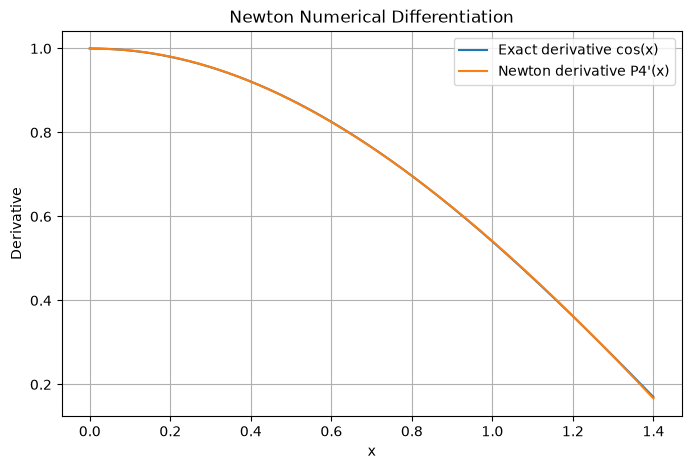

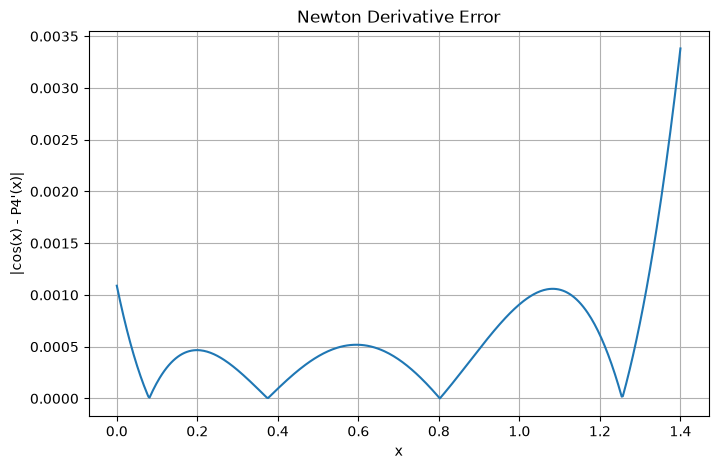

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Function
# =========================================================

def f(x):
    return np.sin(x)


# =========================================================
# Divided-difference table
# =========================================================

def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    # Zeroth-order divided differences
    table[:, 0] = y

    # Higher-order divided differences
    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1]
                - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


# =========================================================
# Newton coefficients
# =========================================================

def newton_coefficients(table):

    return table[0, :]


# =========================================================
# Newton polynomial and derivative
# =========================================================

def newton_value_and_derivative(
    x_data,
    coefficients,
    x
):

    n = len(coefficients)

    # Start with highest-order coefficient
    value = coefficients[n - 1]

    # Derivative of the constant highest-order term
    derivative = 0.0

    # Nested evaluation
    for i in range(n - 2, -1, -1):

        derivative = (
            value
            + (x - x_data[i]) * derivative
        )

        value = (
            coefficients[i]
            + (x - x_data[i]) * value
        )

    return value, derivative


# =========================================================
# Q6 Data
# =========================================================

x_data = np.array([
    0.0,
    0.2,
    0.55,
    1.0,
    1.4
])

y_data = f(x_data)


# =========================================================
# Construct Newton polynomial
# =========================================================

table = divided_difference_table(
    x_data,
    y_data
)

coefficients = newton_coefficients(table)


print("Newton Coefficients:")
print(coefficients)


# =========================================================
# Required evaluation points
# =========================================================

evaluation_points = np.array([
    0.3,
    0.7,
    1.1
])


print("\nDerivative Comparison")
print(
    "x\t\tP4(x)\t\tP4'(x)\t\t"
    "cos(x)\t\tAbsolute Error\tRelative Error"
)


for point in evaluation_points:

    p_value, derivative = (
        newton_value_and_derivative(
            x_data,
            coefficients,
            point
        )
    )

    exact_derivative = np.cos(point)

    absolute_error = abs(
        exact_derivative - derivative
    )

    relative_error = (
        absolute_error
        / abs(exact_derivative)
    )

    print(
        f"{point:.1f}\t\t"
        f"{p_value:.10f}\t"
        f"{derivative:.10f}\t"
        f"{exact_derivative:.10f}\t"
        f"{absolute_error:.10e}\t"
        f"{relative_error:.10e}"
    )


# =========================================================
# Derivative over a dense grid
# =========================================================

x_eval = np.linspace(0, 1.4, 500)

exact_derivative = np.cos(x_eval)

numerical_derivative = np.array([
    newton_value_and_derivative(
        x_data,
        coefficients,
        point
    )[1]
    for point in x_eval
])


# =========================================================
# Error
# =========================================================

derivative_error = np.abs(
    exact_derivative
    - numerical_derivative
)


relative_derivative_error = (
    derivative_error
    / np.abs(exact_derivative)
)


# =========================================================
# Maximum error
# =========================================================

max_error_index = np.argmax(
    derivative_error
)

max_error = derivative_error[
    max_error_index
]

max_error_x = x_eval[
    max_error_index
]


print("\nMaximum Derivative Error:")
print(
    f"Emax = {max_error:.10e}"
)

print(
    f"Location = {max_error_x:.6f}"
)


# =========================================================
# Plot 1: Exact vs numerical derivative
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    exact_derivative,
    label="Exact derivative cos(x)"
)

plt.plot(
    x_eval,
    numerical_derivative,
    label="Newton derivative P4'(x)"
)

plt.xlabel("x")
plt.ylabel("Derivative")

plt.title(
    "Newton Numerical Differentiation"
)

plt.legend()
plt.grid(True)

plt.show()


# =========================================================
# Plot 2: Derivative error
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    derivative_error
)

plt.xlabel("x")

plt.ylabel(
    "|cos(x) - P4'(x)|"
)

plt.title(
    "Newton Derivative Error"
)

plt.grid(True)

plt.show()

In [2]:
def finite_difference_derivative(x, y):

    n = len(x)

    derivative = np.zeros(n)

    # Forward difference at first point
    h = x[1] - x[0]

    derivative[0] = (
        y[1] - y[0]
    ) / h

    # Unequally spaced three-point formula
    for i in range(1, n - 1):

        h1 = x[i] - x[i - 1]
        h2 = x[i + 1] - x[i]

        derivative[i] = (
            -h2 / (h1 * (h1 + h2))
            * y[i - 1]

            + (h2 - h1)
            / (h1 * h2)
            * y[i]

            + h1 / (h2 * (h1 + h2))
            * y[i + 1]
        )

    # Backward difference at last point
    h = x[-1] - x[-2]

    derivative[-1] = (
        y[-1] - y[-2]
    ) / h

    return derivative

In [3]:
def lagrange_value_and_derivative(x_data, y_data, x):

    n = len(x_data)

    value = 0.0
    derivative = 0.0

    for i in range(n):

        # Calculate L_i(x)
        Li = 1.0

        for j in range(n):

            if i != j:

                Li *= (
                    (x - x_data[j])
                    / (x_data[i] - x_data[j])
                )

        # Add function value contribution
        value += y_data[i] * Li

        # Calculate derivative of L_i
        Li_derivative = 0.0

        for k in range(n):

            if k == i:
                continue

            product = 1.0

            for j in range(n):

                if j != i and j != k:

                    product *= (
                        (x - x_data[j])
                        / (x_data[i] - x_data[j])
                    )

            Li_derivative += (
                product
                / (x_data[i] - x_data[k])
            )

        derivative += (
            y_data[i]
            * Li_derivative
        )

    return value, derivative

Divided-Difference Table:
[[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]
 [ 0.19866933  0.92576542 -0.27169635 -0.11521528  0.        ]
 [ 0.52268723  0.70840835 -0.40995469  0.          0.        ]
 [ 0.84147098  0.35994686  0.          0.          0.        ]
 [ 0.98544973  0.          0.          0.          0.        ]]

Newton Coefficients:
[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]

Newton Numerical Differentiation
----------------------------------------------------------------------
x		P4(x)		P4'(x)		cos(x)		Abs Error	Rel Error
0.3		0.2955599305	0.9556103454	0.9553364891	2.7385628739e-04	2.8665950741e-04
0.7		0.6441452289	0.7644649002	0.7648421873	3.7728709349e-04	4.9328750396e-04
1.1		0.8913088992	0.4546473193	0.4535961214	1.0511978761e-03	2.3174754511e-03

Maximum Newton Derivative Error
----------------------------------------
Emax     = 3.3815739590e-03
Location = 1.400000


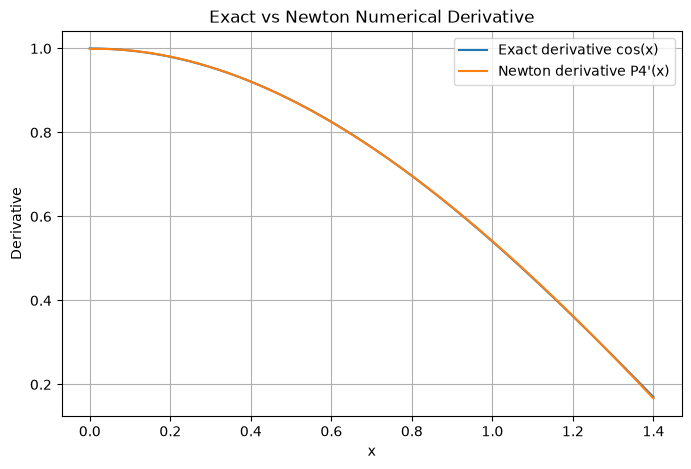

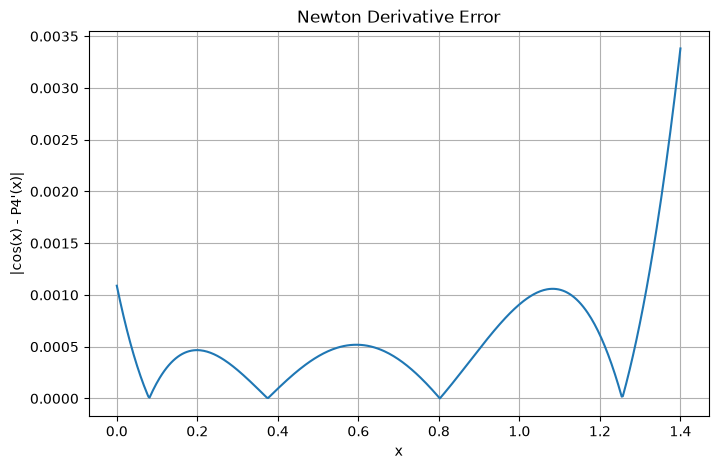

In [4]:
# =========================================================
# Q6 Data
# =========================================================

x_data = np.array([
    0.0,
    0.2,
    0.55,
    1.0,
    1.4
])

y_data = f(x_data)


# =========================================================
# Construct Newton divided-difference table
# =========================================================

table = divided_difference_table(
    x_data,
    y_data
)

print("Divided-Difference Table:")
print(table)


# =========================================================
# Newton coefficients
# =========================================================

coefficients = newton_coefficients(table)

print("\nNewton Coefficients:")
print(coefficients)


# =========================================================
# Required evaluation points
# =========================================================

evaluation_points = np.array([
    0.3,
    0.7,
    1.1
])


# =========================================================
# Newton derivative results
# =========================================================

print("\nNewton Numerical Differentiation")
print("-" * 70)

print(
    "x\t\tP4(x)\t\tP4'(x)\t\t"
    "cos(x)\t\tAbs Error\tRel Error"
)

for point in evaluation_points:

    p_value, derivative = newton_value_and_derivative(
        x_data,
        coefficients,
        point
    )

    exact_derivative = np.cos(point)

    absolute_error = abs(
        exact_derivative - derivative
    )

    relative_error = (
        absolute_error /
        abs(exact_derivative)
    )

    print(
        f"{point:.1f}\t\t"
        f"{p_value:.10f}\t"
        f"{derivative:.10f}\t"
        f"{exact_derivative:.10f}\t"
        f"{absolute_error:.10e}\t"
        f"{relative_error:.10e}"
    )


# =========================================================
# Evaluate Newton derivative on dense grid
# =========================================================

x_eval = np.linspace(0, 1.4, 500)

exact_derivative = np.cos(x_eval)

newton_derivative = np.array([
    newton_value_and_derivative(
        x_data,
        coefficients,
        point
    )[1]
    for point in x_eval
])


# =========================================================
# Newton derivative error
# =========================================================

newton_error = np.abs(
    exact_derivative - newton_derivative
)


# Maximum error
max_error_index = np.argmax(newton_error)

max_error = newton_error[max_error_index]

max_error_x = x_eval[max_error_index]


print("\nMaximum Newton Derivative Error")
print("-" * 40)

print(f"Emax     = {max_error:.10e}")
print(f"Location = {max_error_x:.6f}")


# =========================================================
# Plot 1
# Exact derivative vs Newton derivative
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    exact_derivative,
    label="Exact derivative cos(x)"
)

plt.plot(
    x_eval,
    newton_derivative,
    label="Newton derivative P4'(x)"
)

plt.xlabel("x")
plt.ylabel("Derivative")

plt.title(
    "Exact vs Newton Numerical Derivative"
)

plt.legend()
plt.grid(True)

plt.show()


# =========================================================
# Plot 2
# Newton derivative error
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    newton_error
)

plt.xlabel("x")
plt.ylabel("|cos(x) - P4'(x)|")

plt.title(
    "Newton Derivative Error"
)

plt.grid(True)

plt.show()

In [5]:
# =========================================================
# Compare Newton, Lagrange and Finite Difference
# =========================================================

# ---------------------------------------------------------
# Finite difference derivative at data points
# ---------------------------------------------------------

fd_derivative = finite_difference_derivative(
    x_data,
    y_data
)


# ---------------------------------------------------------
# Newton derivative at data points
# ---------------------------------------------------------

newton_derivative_data = np.array([
    newton_value_and_derivative(
        x_data,
        coefficients,
        point
    )[1]
    for point in x_data
])


# ---------------------------------------------------------
# Lagrange derivative at data points
# ---------------------------------------------------------

lagrange_derivative_data = np.array([
    lagrange_value_and_derivative(
        x_data,
        y_data,
        point
    )[1]
    for point in x_data
])


# ---------------------------------------------------------
# Exact derivative
# ---------------------------------------------------------

exact_derivative_data = np.cos(x_data)


# =========================================================
# Print comparison
# =========================================================

print("\nThree-Method Derivative Comparison")
print("-" * 90)

print(
    "x\t\tExact\t\t"
    "Finite Difference\t"
    "Lagrange\t"
    "Newton"
)

for i in range(len(x_data)):

    print(
        f"{x_data[i]:.2f}\t\t"
        f"{exact_derivative_data[i]:.10f}\t"
        f"{fd_derivative[i]:.10f}\t\t"
        f"{lagrange_derivative_data[i]:.10f}\t"
        f"{newton_derivative_data[i]:.10f}"
    )


Three-Method Derivative Comparison
------------------------------------------------------------------------------------------
x		Exact		Finite Difference	Lagrange	Newton
0.00		1.0000000000	0.9933466540		0.9989108160	0.9989108160
0.20		0.9800665778	0.9687716610		0.9805334016	0.9805334016
0.55		0.8525245221	0.8306717021		0.8520316924	0.8520316924
1.00		0.5403023059	0.5239287375		0.5412108614	0.5412108614
1.40		0.1699671429	0.3599468630		0.1665855689	0.1665855689


In [6]:
# =========================================================
# Calculate errors
# =========================================================

fd_error = np.abs(
    exact_derivative_data - fd_derivative
)

lagrange_error = np.abs(
    exact_derivative_data
    - lagrange_derivative_data
)

newton_error_data = np.abs(
    exact_derivative_data
    - newton_derivative_data
)


# =========================================================
# Maximum errors
# =========================================================

print("\nMaximum Errors")
print("-" * 40)

print(
    f"Finite Difference : "
    f"{np.max(fd_error):.10e}"
)

print(
    f"Lagrange          : "
    f"{np.max(lagrange_error):.10e}"
)

print(
    f"Newton            : "
    f"{np.max(newton_error_data):.10e}"
)


Maximum Errors
----------------------------------------
Finite Difference : 1.8997972005e-01
Lagrange          : 3.3815739590e-03
Newton            : 3.3815739590e-03


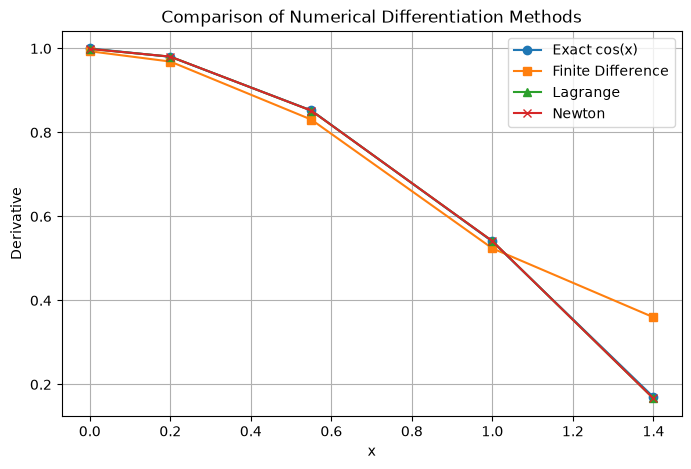

In [7]:
# =========================================================
# Plot: Three derivative methods
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_data,
    exact_derivative_data,
    marker="o",
    label="Exact cos(x)"
)

plt.plot(
    x_data,
    fd_derivative,
    marker="s",
    label="Finite Difference"
)

plt.plot(
    x_data,
    lagrange_derivative_data,
    marker="^",
    label="Lagrange"
)

plt.plot(
    x_data,
    newton_derivative_data,
    marker="x",
    label="Newton"
)

plt.xlabel("x")
plt.ylabel("Derivative")

plt.title(
    "Comparison of Numerical Differentiation Methods"
)

plt.legend()
plt.grid(True)

plt.show()

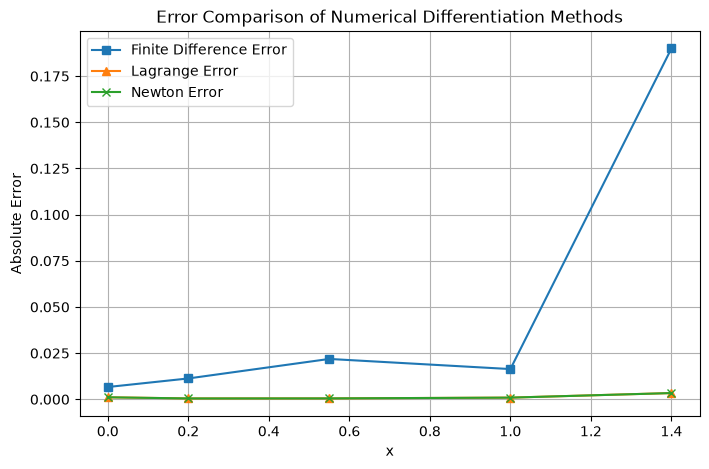

In [8]:
# =========================================================
# Plot: Error comparison
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_data,
    fd_error,
    marker="s",
    label="Finite Difference Error"
)

plt.plot(
    x_data,
    lagrange_error,
    marker="^",
    label="Lagrange Error"
)

plt.plot(
    x_data,
    newton_error_data,
    marker="x",
    label="Newton Error"
)

plt.xlabel("x")
plt.ylabel("Absolute Error")

plt.title(
    "Error Comparison of Numerical Differentiation Methods"
)

plt.legend()
plt.grid(True)

plt.show()